# Machine Learning-Based Intrusion Detection System

**Import Required Libraries**

In [48]:
# Import Required Libraries
# Machine Learning-Based Intrusion Detection System

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Handling imbalanced datasets
from imblearn.over_sampling import SMOTE

# Splitting dataset
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.utils import to_categorical

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Measure execution time
import time

print("All required libraries imported successfully.")

All required libraries imported successfully.


**Load the CICIDS2017 Dataset**

In [ ]:
# Upload Dataset in Google Colab

from google.colab import files

uploaded = files.upload()

Saving Tuesday-WorkingHours.pcap_ISCX.csv to Tuesday-WorkingHours.pcap_ISCX.csv


In [49]:
# Read the CSV Dataset

# Replace filename if required
df = pd.read_csv("Tuesday-WorkingHours.pcap_ISCX.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


**Explore the Dataset**

In [50]:
# Display Dataset Information

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("First Five Records")
print("="*60)

display(df.head())

Dataset Shape
(445909, 79)


First Five Records


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [51]:
# Display Column Names

print("Columns in Dataset\n")

for column in df.columns:
    print(column)

Columns in Dataset

 Destination Port
 Flow Duration
 Total Fwd Packets
 Total Backward Packets
Total Length of Fwd Packets
 Total Length of Bwd Packets
 Fwd Packet Length Max
 Fwd Packet Length Min
 Fwd Packet Length Mean
 Fwd Packet Length Std
Bwd Packet Length Max
 Bwd Packet Length Min
 Bwd Packet Length Mean
 Bwd Packet Length Std
Flow Bytes/s
 Flow Packets/s
 Flow IAT Mean
 Flow IAT Std
 Flow IAT Max
 Flow IAT Min
Fwd IAT Total
 Fwd IAT Mean
 Fwd IAT Std
 Fwd IAT Max
 Fwd IAT Min
Bwd IAT Total
 Bwd IAT Mean
 Bwd IAT Std
 Bwd IAT Max
 Bwd IAT Min
Fwd PSH Flags
 Bwd PSH Flags
 Fwd URG Flags
 Bwd URG Flags
 Fwd Header Length
 Bwd Header Length
Fwd Packets/s
 Bwd Packets/s
 Min Packet Length
 Max Packet Length
 Packet Length Mean
 Packet Length Std
 Packet Length Variance
FIN Flag Count
 SYN Flag Count
 RST Flag Count
 PSH Flag Count
 ACK Flag Count
 URG Flag Count
 CWE Flag Count
 ECE Flag Count
 Down/Up Ratio
 Average Packet Size
 Avg Fwd Segment Size
 Avg Bwd Segment Size
 Fwd Hea

In [52]:
# Dataset Information

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445909 entries, 0 to 445908
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             445909 non-null  int64  
 1    Flow Duration                445909 non-null  int64  
 2    Total Fwd Packets            445909 non-null  int64  
 3    Total Backward Packets       445909 non-null  int64  
 4   Total Length of Fwd Packets   445909 non-null  int64  
 5    Total Length of Bwd Packets  445909 non-null  int64  
 6    Fwd Packet Length Max        445909 non-null  int64  
 7    Fwd Packet Length Min        445909 non-null  int64  
 8    Fwd Packet Length Mean       445909 non-null  float64
 9    Fwd Packet Length Std        445909 non-null  float64
 10  Bwd Packet Length Max         445909 non-null  int64  
 11   Bwd Packet Length Min        445909 non-null  int64  
 12   Bwd Packet Length Mean 

In [53]:
# Summary Statistics

print("="*60)
print("Summary Statistics")
print("="*60)

display(df.describe())

Summary Statistics


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,445909.000000,4.459090e+05,445909.000000,445909.000000,4.459090e+05,4.459090e+05,445909.000000,445909.000000,445909.000000,445909.000000,...,445909.000000,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05,4.459090e+05
mean,8878.375745,1.077944e+07,11.800473,13.907212,5.302105e+02,2.186324e+04,173.346669,20.579979,48.528489,49.897094,...,2.088341,-1.321786e+04,7.265964e+04,4.670517e+04,1.642092e+05,4.828426e+04,3.294459e+06,1.497105e+05,3.407025e+06,3.145407e+06
std,19522.889728,2.955629e+07,867.072428,1172.161547,5.676904e+03,2.625768e+06,472.450792,38.938350,113.195021,146.736325,...,6.325197,2.666478e+06,6.205625e+05,3.601504e+05,1.049887e+06,5.649489e+05,1.258776e+07,1.982346e+06,1.293249e+07,1.240892e+07
min,0.000000,-4.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.860000e+02,2.000000,1.000000,4.000000e+00,0.000000e+00,1.000000,0.000000,0.857143,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.128800e+04,2.000000,2.000000,6.800000e+01,1.360000e+02,41.000000,0.000000,37.000000,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,4.668200e+05,4.000000,2.000000,1.500000e+02,3.360000e+02,62.000000,41.000000,50.000000,21.920310,...,2.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65505.000000,1.200000e+08,206446.000000,276072.000000,2.428415e+06,6.270000e+08,24820.000000,2065.000000,4672.000000,5398.072094,...,1846.000000,1.380000e+02,1.070000e+08,2.410000e+07,1.070000e+08,1.070000e+08,1.200000e+08,7.590000e+07,1.200000e+08,1.200000e+08


**Missing Value Analysis**

In [54]:
# Check Missing Values

missing = df.isnull().sum()

missing = missing[missing > 0]

print("Columns containing missing values")

display(missing)

Columns containing missing values


,0
Flow Bytes/s,201


**Dataset Cleaning**

In [55]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 24065


In [ ]:
# Remove Duplicate Records

df = df.drop_duplicates()

print("Duplicate records removed.")

print("New Shape")

print(df.shape)

Duplicate records removed.
New Shape
(421844, 79)


In [ ]:
# Replace Infinite Values

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

print("Infinite values removed.")

print(df.shape)

Infinite values removed.
(421626, 79)


**Class Distribution**

In [ ]:
import pandas as pd

# Class Distribution

print(df[" Label"].value_counts())

 Label
BENIGN         412476
FTP-Patator      5931
SSH-Patator      3219
Name: count, dtype: int64


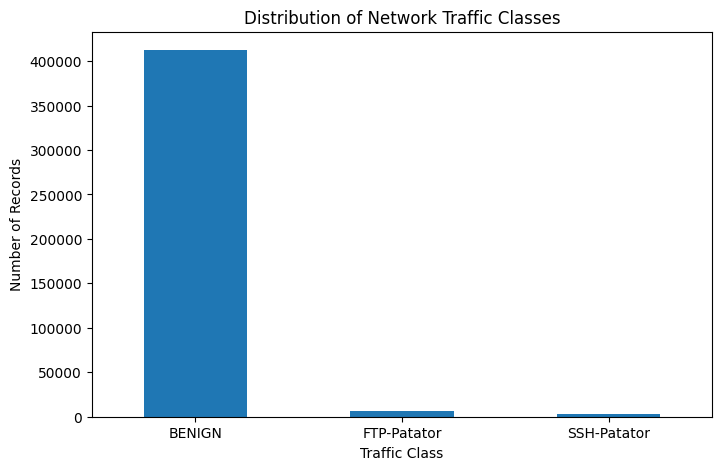

In [ ]:
# Plot Class Distribution

plt.figure(figsize=(8,5))

df[" Label"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Traffic Classes")

plt.xlabel("Traffic Class")

plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.show()

**Data Preprocessing**

In [ ]:
# Encode Target Variable

# Display original class labels
print("Original Class Labels:")
print(df[" Label"].unique())

# Create Label Encoder
label_encoder = LabelEncoder()

# Encode labels
df[" Label"] = label_encoder.fit_transform(df[" Label"])

# Display encoded classes
print("\nEncoded Classes:")

for index, label in enumerate(label_encoder.classes_):
    print(f"{label} --> {index}")

Original Class Labels:
['BENIGN' 'FTP-Patator' 'SSH-Patator']

Encoded Classes:
BENIGN --> 0
FTP-Patator --> 1
SSH-Patator --> 2


In [ ]:
# Separate Features and Target Variable

X = df.drop(" Label", axis=1)

y = df[" Label"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (421626, 78)
Target Vector Shape : (421626,)


In [ ]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (337300, 78)
Testing Features : (84326, 78)

Training Labels : (337300,)
Testing Labels : (84326,)


In [ ]:
# Standardise Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [ ]:
# Class Distribution Before SMOTE

print("Training Class Distribution Before SMOTE\n")

print(pd.Series(y_train).value_counts())

Training Class Distribution Before SMOTE

 Label
0    329980
1      4745
2      2575
Name: count, dtype: int64


In [ ]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE Applied Successfully.")

SMOTE Applied Successfully.


In [ ]:
# Class Distribution After SMOTE

print("Training Class Distribution After SMOTE\n")

print(pd.Series(y_train_smote).value_counts())

Training Class Distribution After SMOTE

 Label
2    329980
0    329980
1    329980
Name: count, dtype: int64


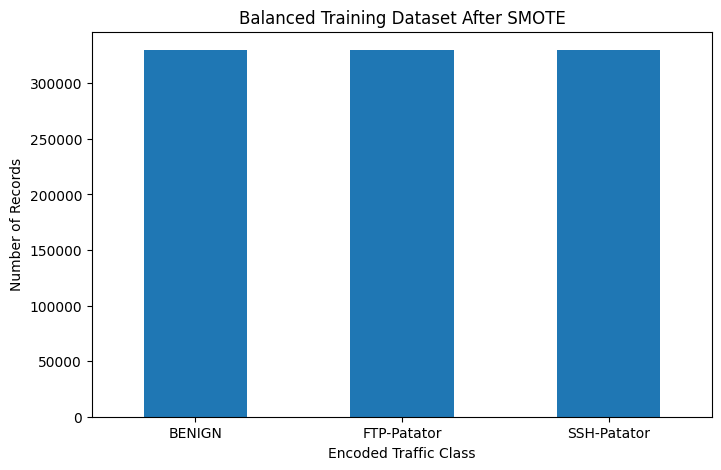

In [ ]:
# Plot Class Distribution After SMOTE

plt.figure(figsize=(8,5))

pd.Series(y_train_smote).value_counts().sort_index().plot(kind="bar")

plt.title("Balanced Training Dataset After SMOTE")

plt.xlabel("Encoded Traffic Class")

plt.ylabel("Number of Records")

plt.xticks(
    ticks=[0,1,2],
    labels=label_encoder.classes_,
    rotation=0
)

plt.show()

**Model 1 – Decision Tree Classifier**

In [ ]:
# Decision Tree Classifier

# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Record training start time
start_train = time.time()

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(
    X_train_smote,
    y_train_smote
)

# Record training end time
end_train = time.time()

# Calculate training time
dt_training_time = end_train - start_train

print(f"Decision Tree Training Time : {dt_training_time:.4f} seconds")

Decision Tree Training Time : 34.5060 seconds


In [ ]:
# Predict Test Dataset

# Record prediction time
start_test = time.time()

# Predict labels
dt_predictions = dt_model.predict(X_test_scaled)

# Prediction end time
end_test = time.time()

# Detection time
dt_detection_time = end_test - start_test

print(f"Decision Tree Detection Time : {dt_detection_time:.4f} seconds")

Decision Tree Detection Time : 0.0168 seconds


In [ ]:
# Accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print(f"Accuracy : {dt_accuracy:.4f}")

Accuracy : 1.0000


In [ ]:
# Precision

dt_precision = precision_score(
    y_test,
    dt_predictions,
    average="weighted"
)

print(f"Precision : {dt_precision:.4f}")

Precision : 1.0000


In [ ]:
# Recall

dt_recall = recall_score(
    y_test,
    dt_predictions,
    average="weighted"
)

print(f"Recall : {dt_recall:.4f}")

Recall : 1.0000


In [ ]:
# F1 Score

dt_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted"
)

print(f"F1 Score : {dt_f1:.4f}")

F1 Score : 1.0000


In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    dt_predictions
)

print(cm)

[[82496     0     0]
 [    0  1186     0]
 [    0     0   644]]


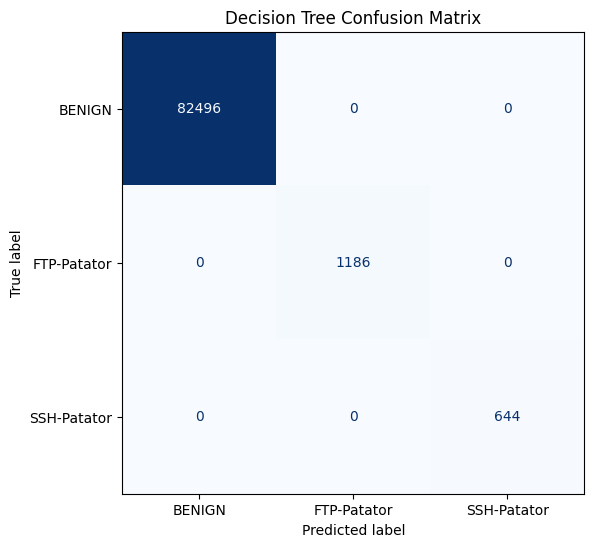

In [ ]:
# Plot Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
# Classification Report

print(
    classification_report(
        y_test,
        dt_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82496
 FTP-Patator       1.00      1.00      1.00      1186
 SSH-Patator       1.00      1.00      1.00       644

    accuracy                           1.00     84326
   macro avg       1.00      1.00      1.00     84326
weighted avg       1.00      1.00      1.00     84326



In [ ]:
# False Positive Rate

cm = confusion_matrix(y_test, dt_predictions)

FP = cm.sum(axis=0) - np.diag(cm)
TN = cm.sum() - (FP + (cm.sum(axis=1) - np.diag(cm)) + np.diag(cm))

fpr = FP / (FP + TN)

print("False Positive Rate for each class:\n")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {fpr[i]:.6f}")

print("\nAverage False Positive Rate:", np.mean(fpr))

False Positive Rate for each class:

BENIGN: 0.000000
FTP-Patator: 0.000000
SSH-Patator: 0.000000

Average False Positive Rate: 0.0


In [ ]:
# ROC-AUC Score

from sklearn.preprocessing import label_binarize

# Predict probabilities
dt_probabilities = dt_model.predict_proba(X_test_scaled)

# Convert target into binary format
y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

# ROC-AUC
dt_auc = roc_auc_score(
    y_test_bin,
    dt_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC Score : {dt_auc:.4f}")

ROC-AUC Score : 1.0000


**Model 2: Random Forest Classifier**

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Record training time
start_train = time.time()

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Training time
end_train = time.time()

rf_training_time = end_train - start_train

print(f"Random Forest Training Time : {rf_training_time:.4f} seconds")

Random Forest Training Time : 211.6546 seconds


In [ ]:
# Predict Test Dataset

start_test = time.time()

rf_predictions = rf_model.predict(X_test_scaled)

end_test = time.time()

rf_detection_time = end_test - start_test

print(f"Random Forest Detection Time : {rf_detection_time:.4f} seconds")

Random Forest Detection Time : 0.7433 seconds


In [ ]:
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Accuracy : {rf_accuracy:.4f}")

Accuracy : 1.0000


In [ ]:
# Precision
rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print(f"Precision : {rf_precision:.4f}")

Precision : 1.0000


In [ ]:
# Recall
rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print(f"Recall : {rf_recall:.4f}")

Recall : 1.0000


In [ ]:
# F1 Score
rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print(f"F1 Score : {rf_f1:.4f}")

F1 Score : 1.0000


In [ ]:
# Confusion Matrix
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[82496     0     0]
 [    0  1186     0]
 [    4     0   640]]


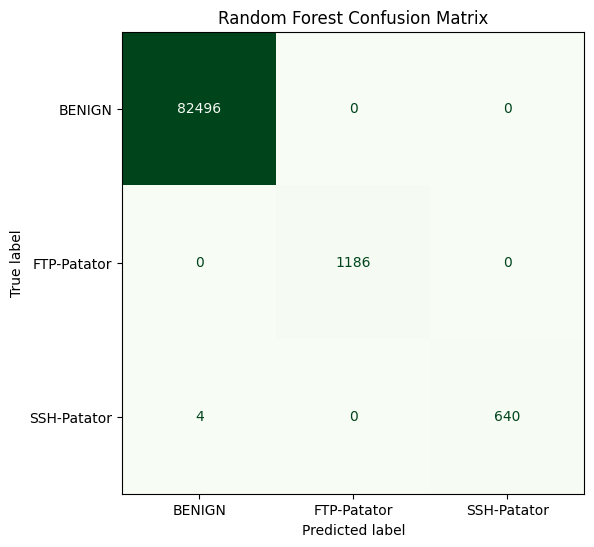

In [ ]:
# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
# Random Forest Feature Importance

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print("Top 15 Most Important Features")

display(feature_importance.head(15))

Top 15 Most Important Features


,Feature,Importance
0,Destination Port,0.145068
35,Bwd Header Length,0.055213
9,Fwd Packet Length Std,0.049080
68,act_data_pkt_fwd,0.048436
62,Subflow Fwd Packets,0.044834
52,Average Packet Size,0.039863
39,Max Packet Length,0.036564
40,Packet Length Mean,0.036339
55,Fwd Header Length.1,0.036067
3,Total Backward Packets,0.034803


In [ ]:
# Classification Report
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82496
 FTP-Patator       1.00      1.00      1.00      1186
 SSH-Patator       1.00      0.99      1.00       644

    accuracy                           1.00     84326
   macro avg       1.00      1.00      1.00     84326
weighted avg       1.00      1.00      1.00     84326



In [ ]:
# False Positive Rate
FP = rf_cm.sum(axis=0) - np.diag(rf_cm)

TN = rf_cm.sum() - (
    FP +
    (rf_cm.sum(axis=1) - np.diag(rf_cm)) +
    np.diag(rf_cm)
)

rf_fpr = FP / (FP + TN)

print("False Positive Rate:\n")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {rf_fpr[i]:.6f}")

print("\nAverage False Positive Rate:", np.mean(rf_fpr))

False Positive Rate:

BENIGN: 0.002186
FTP-Patator: 0.000000
SSH-Patator: 0.000000

Average False Positive Rate: 0.0007285974499089253


In [ ]:
# ROC-AUC
rf_probabilities = rf_model.predict_proba(X_test_scaled)

rf_auc = roc_auc_score(
    y_test_bin,
    rf_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC Score : {rf_auc:.4f}")

ROC-AUC Score : 1.0000


In [ ]:
# Random Forest Feature Importance

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print("Top 15 Most Important Features")

display(feature_importance.head(15))

Top 15 Most Important Features


,Feature,Importance
0,Destination Port,0.145068
35,Bwd Header Length,0.055213
9,Fwd Packet Length Std,0.049080
68,act_data_pkt_fwd,0.048436
62,Subflow Fwd Packets,0.044834
52,Average Packet Size,0.039863
39,Max Packet Length,0.036564
40,Packet Length Mean,0.036339
55,Fwd Header Length.1,0.036067
3,Total Backward Packets,0.034803


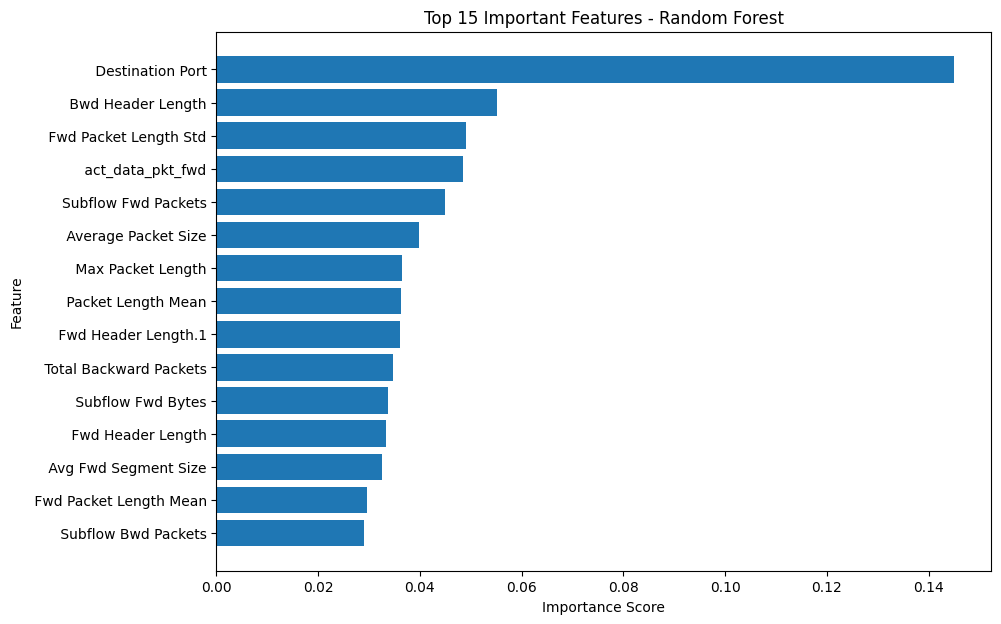

In [ ]:
# Plot Top 15 Important Features

top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.title("Top 15 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

**Model 3: Support Vector Machine (SVM)**

In [ ]:
# Import Required Libraries

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
# Train Linear Support Vector Machine

# Record training start time
start_train = time.time()

# Create Linear SVM model
svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_smote,
    y_train_smote
)


# Record training end time
end_train = time.time()

# Calculate training time
svm_training_time = end_train - start_train

print(f"SVM Training Time : {svm_training_time:.4f} seconds")

SVM Training Time : 4219.9942 seconds


In [56]:
# Predict Test Dataset

start_test = time.time()

svm_predictions = svm_model.predict(X_test_scaled)

end_test = time.time()

svm_detection_time = end_test - start_test

print(f"SVM Detection Time : {svm_detection_time:.4f} seconds")

SVM Detection Time : 0.3057 seconds


In [57]:
# Accuracy

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(f"Accuracy : {svm_accuracy:.4f}")

Accuracy : 0.9900


In [58]:
# Precision

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted"
)

print(f"Precision : {svm_precision:.4f}")

Precision : 0.9952


In [59]:
# Recall

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted"
)

print(f"Recall : {svm_recall:.4f}")

Recall : 0.9900


In [60]:
# F1 Score

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted"
)

print(f"F1 Score : {svm_f1:.4f}")

F1 Score : 0.9917


In [61]:
# Confusion Matrix

svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

print(svm_cm)

[[81656    44   796]
 [    2  1183     1]
 [    3     1   640]]


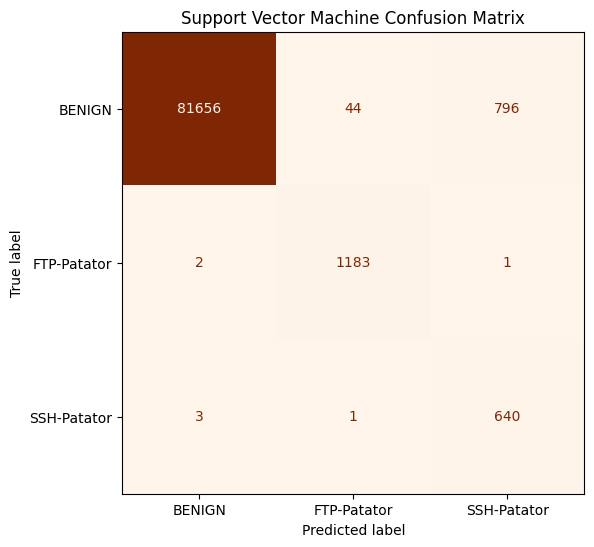

In [62]:
# Plot Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=False
)

plt.title("Support Vector Machine Confusion Matrix")

plt.show()

In [63]:
# Classification Report

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99     82496
 FTP-Patator       0.96      1.00      0.98      1186
 SSH-Patator       0.45      0.99      0.62       644

    accuracy                           0.99     84326
   macro avg       0.80      0.99      0.86     84326
weighted avg       1.00      0.99      0.99     84326



In [64]:
# False Positive Rate

FP = svm_cm.sum(axis=0) - np.diag(svm_cm)

TN = svm_cm.sum() - (
    FP +
    (svm_cm.sum(axis=1) - np.diag(svm_cm)) +
    np.diag(svm_cm)
)

svm_fpr = FP / (FP + TN)

print("False Positive Rate:\n")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {svm_fpr[i]:.6f}")

print("\nAverage False Positive Rate:", np.mean(svm_fpr))

False Positive Rate:

BENIGN: 0.002732
FTP-Patator: 0.000541
SSH-Patator: 0.009524

Average False Positive Rate: 0.004265882367609439


In [66]:
from sklearn.calibration import CalibratedClassifierCV

# ROC-AUC Score

# Calibrate the LinearSVC model to get probability estimates
calibrated_svm = CalibratedClassifierCV(svm_model, method='sigmoid', cv='prefit')
calibrated_svm.fit(X_train_smote, y_train_smote) # Fit on the training data used for svm_model

svm_probabilities = calibrated_svm.predict_proba(X_test_scaled)

svm_auc = roc_auc_score(
    y_test_bin,
    svm_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC Score : {svm_auc:.4f}")

ROC-AUC Score : 0.9998


**Model 4: Long Short-Term Memory (LSTM)**

In [67]:
# Reshape Data for LSTM

# Convert training data into NumPy arrays
X_train_lstm = np.array(X_train_scaled)
X_test_lstm = np.array(X_test_scaled)

# Reshape input for LSTM
# Shape becomes:
# (samples, timesteps, features)

X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    1,
    X_train_lstm.shape[1]
)

X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    1,
    X_test_lstm.shape[1]
)

print("Training Shape :", X_train_lstm.shape)
print("Testing Shape :", X_test_lstm.shape)

Training Shape : (337300, 1, 78)
Testing Shape : (84326, 1, 78)


In [68]:
# One-Hot Encode Labels

y_train_lstm = to_categorical(y_train)

y_test_lstm = to_categorical(y_test)

print("Labels converted successfully.")

Labels converted successfully.


In [69]:
# Build LSTM Model

lstm_model = Sequential()

# LSTM Layer
lstm_model.add(
    LSTM(
        64,
        input_shape=(1,78)
    )
)

# Hidden Layer
lstm_model.add(
    Dense(
        32,
        activation="relu"
    )
)

# Output Layer
lstm_model.add(
    Dense(
        3,
        activation="softmax"
    )
)

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(lstm_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        36,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,787 (151.51 KB)

 Trainable params: 38,787 (151.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [70]:
# Train LSTM

start_train = time.time()

history = lstm_model.fit(

    X_train_lstm,
    y_train_lstm,

    epochs=10,
    batch_size=512,

    validation_split=0.20,

    verbose=1

)

end_train = time.time()

lstm_training_time = end_train - start_train

print(f"LSTM Training Time : {lstm_training_time:.4f} seconds")

Epoch 1/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9876 - loss: 0.0818 - val_accuracy: 0.9986 - val_loss: 0.0090
Epoch 2/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9986 - loss: 0.0076 - val_accuracy: 0.9990 - val_loss: 0.0054
Epoch 3/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9988 - loss: 0.0058 - val_accuracy: 0.9990 - val_loss: 0.0044
Epoch 4/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9989 - loss: 0.0048 - val_accuracy: 0.9991 - val_loss: 0.0036
Epoch 5/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9992 - val_loss: 0.0035
Epoch 6/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 0.9993 - val_loss: 0.0029
Epoch 7/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0025
Epoch 8/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9992 - loss: 0.0027 - val_a

In [71]:
# Predict Test Dataset

start_test = time.time()

lstm_probabilities = lstm_model.predict(X_test_lstm)

lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

end_test = time.time()

lstm_detection_time = end_test - start_test

print(f"LSTM Detection Time : {lstm_detection_time:.4f} seconds")

2636/2636 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
LSTM Detection Time : 19.7321 seconds


In [72]:
# Accuracy

lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

print(f"Accuracy : {lstm_accuracy:.4f}")

Accuracy : 0.9993


In [73]:
# Precision
lstm_precision = precision_score(
    y_test,
    lstm_predictions,
    average="weighted"
)

print(f"Precision : {lstm_precision:.4f}")

Precision : 0.9993


In [74]:
# Recall
lstm_recall = recall_score(
    y_test,
    lstm_predictions,
    average="weighted"
)

print(f"Recall : {lstm_recall:.4f}")

Recall : 0.9993


In [75]:
# F1 Score
lstm_f1 = f1_score(
    y_test,
    lstm_predictions,
    average="weighted"
)

print(f"F1 Score : {lstm_f1:.4f}")

F1 Score : 0.9993


In [76]:
# Confusion Matrix
lstm_cm = confusion_matrix(
    y_test,
    lstm_predictions
)

print(lstm_cm)

[[82490     6     0]
 [    3  1183     0]
 [   51     1   592]]


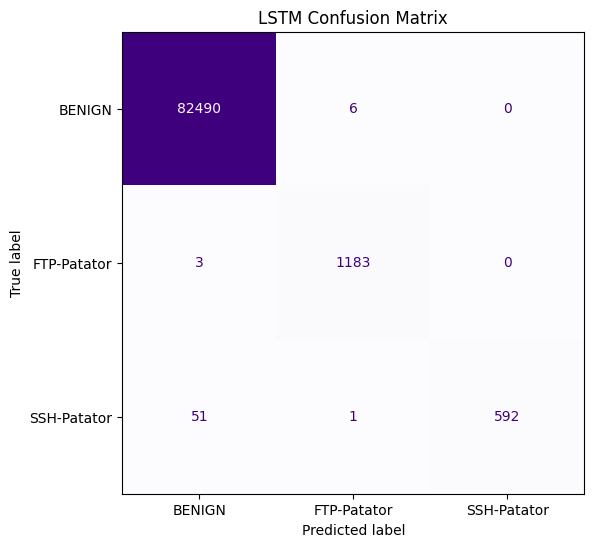

In [77]:
# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm_cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Purples",
    ax=ax,
    colorbar=False
)

plt.title("LSTM Confusion Matrix")

plt.show()

In [78]:
# Classification Report
print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82496
 FTP-Patator       0.99      1.00      1.00      1186
 SSH-Patator       1.00      0.92      0.96       644

    accuracy                           1.00     84326
   macro avg       1.00      0.97      0.98     84326
weighted avg       1.00      1.00      1.00     84326



In [79]:
# False Positive Rate
FP = lstm_cm.sum(axis=0) - np.diag(lstm_cm)

TN = lstm_cm.sum() - (
    FP +
    (lstm_cm.sum(axis=1) - np.diag(lstm_cm)) +
    np.diag(lstm_cm)
)

lstm_fpr = FP / (FP + TN)

print("False Positive Rate:\n")

for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {lstm_fpr[i]:.6f}")

print("\nAverage False Positive Rate:", np.mean(lstm_fpr))

False Positive Rate:

BENIGN: 0.029508
FTP-Patator: 0.000084
SSH-Patator: 0.000000

Average False Positive Rate: 0.009864130684828146


In [80]:
# ROC-AUC
lstm_auc = roc_auc_score(
    y_test_lstm,
    lstm_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC Score : {lstm_auc:.4f}")

ROC-AUC Score : 0.9998


**Final Comparison Table**

In [82]:
# Model Performance Comparison

# Re-calculate rf_recall to ensure it's defined
rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "LSTM"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        lstm_accuracy
    ],

    "Precision":[
        dt_precision,
        rf_precision,
        svm_precision,
        lstm_precision
    ],

    "Recall":[
        dt_recall,
        rf_recall,
        svm_recall,
        lstm_recall
    ],

    "F1 Score":[
        dt_f1,
        rf_f1,
        svm_f1,
        lstm_f1
    ],

    "ROC-AUC":[
        dt_auc,
        rf_auc,
        svm_auc,
        lstm_auc
    ],

    "False Positive Rate":[
        np.mean(fpr),
        np.mean(rf_fpr),
        np.mean(svm_fpr),
        np.mean(lstm_fpr)
    ],

    "Training Time (s)":[
        dt_training_time,
        rf_training_time,
        svm_training_time,
        lstm_training_time
    ],

    "Detection Time (s)":[
        dt_detection_time,
        rf_detection_time,
        svm_detection_time,
        lstm_detection_time
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positive Rate,Training Time (s),Detection Time (s)
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,34.506048,0.016766
1,Random Forest,0.999953,0.999953,0.999953,0.999952,1.000000,0.000729,211.654593,0.743340
2,Support Vector Machine,0.989956,0.995189,0.989956,0.991745,0.999756,0.004266,4219.994212,0.305676
3,LSTM,0.999277,0.999277,0.999277,0.999264,0.999845,0.009864,98.009734,19.732087


In [83]:
# Save Results
comparison.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


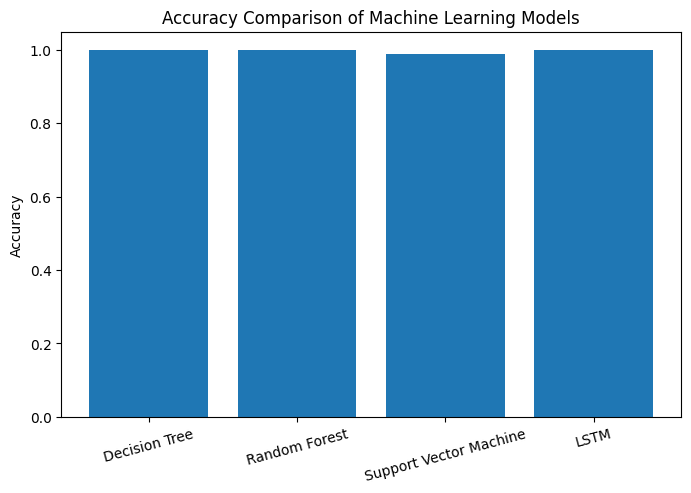

In [84]:
# Accuracy Comparision
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

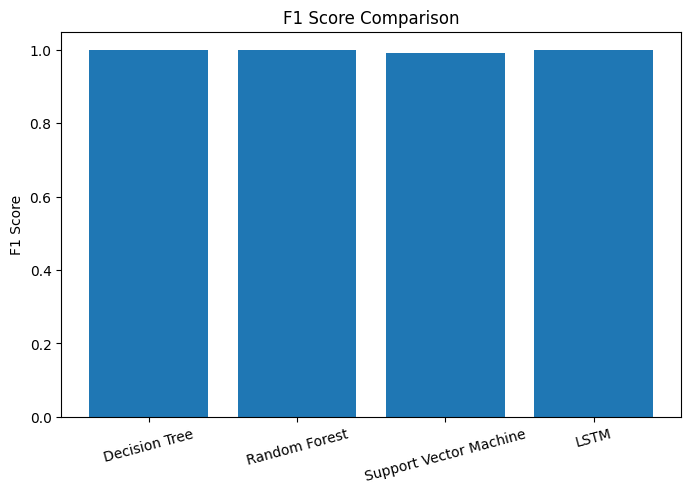

In [85]:
# F1 Score Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

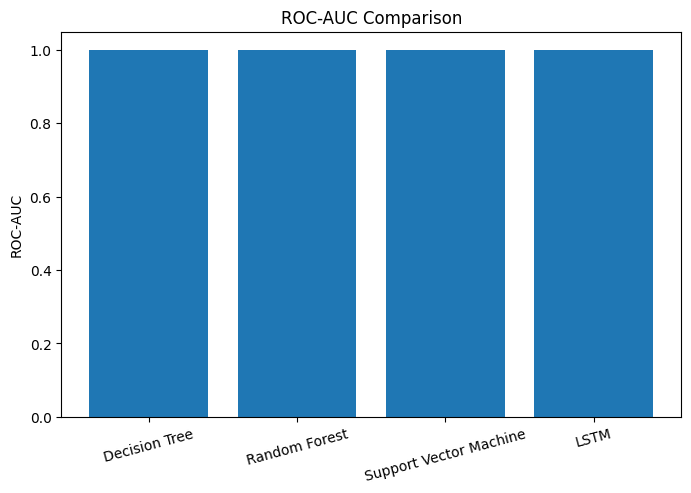

In [86]:
# ROC-AUC Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.show()

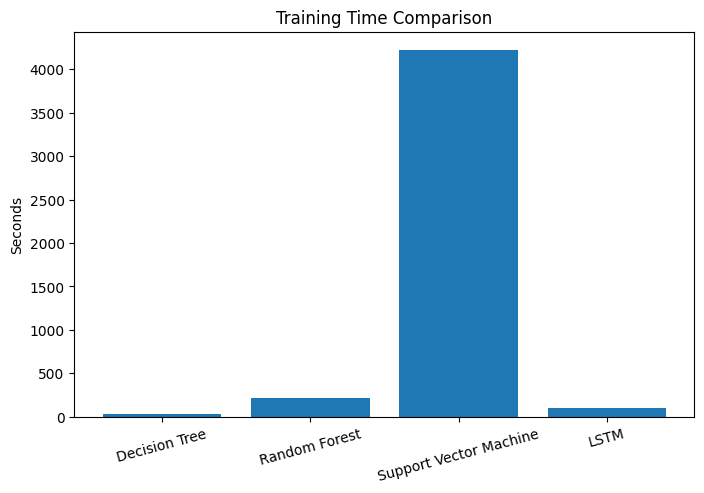

In [87]:
# Training Time Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Training Time (s)"]
)

plt.title("Training Time Comparison")

plt.ylabel("Seconds")

plt.xticks(rotation=15)

plt.show()

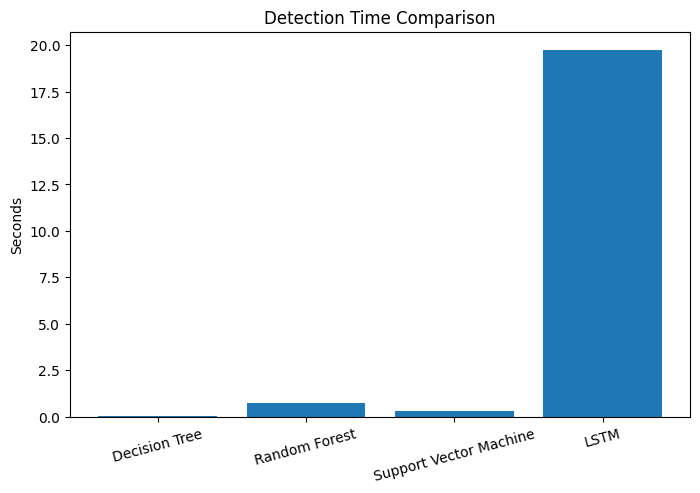

In [88]:
# Detection Time Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Detection Time (s)"]
)

plt.title("Detection Time Comparison")

plt.ylabel("Seconds")

plt.xticks(rotation=15)

plt.show()